# Gomoku

**Task:** Implement a Gomoku game in your terminal so we can play together. To be clear, I want to play against you, not another program!

This notebook records the Fibona agent building and playing a terminal Gomoku game with the user. The user plays Black; the agent chooses each White move itself. Code handles the board, input, and rules. The cells and outputs capture the session, with a screenshot at the end.


In [1]:
response = call_me(input="Start the user's task and submit the first Python cell.")
print(response.output_text)

In [2]:
import inspect
var_docs = {}
print("Let's play Gomoku. You'll be Black (●) and move first; I'll be White (○). I'll personally choose my moves—no separate game-playing engine. Five or more in a row wins. I'll set up a clickable 15×15 board in this terminal.")
ui_context = {"terminal_type": str(type(terminal)), "source_files": list(source_code), "app_class": inspect.getsource(type(terminal))}
var_docs['ui_context'] = 'Terminal app implementation and runtime source filenames, for integrating the game UI.'
r = call_me(input='Task: implement interactive Gomoku in the terminal; user plays against YOU, not another program. Need UI integration, and each AI move must be chosen by you via call_me, not call_llm_api or a game engine. Inspect terminal implementation below and choose next cell to build UI. ui_context stores full details.\n' + str(ui_context))
print(r.output_text)

Let's play Gomoku. You'll be Black (●) and move first; I'll be White (○). I'll personally choose my moves—no separate game-playing engine. Five or more in a row wins. I'll set up a clickable 15×15 board in this terminal.


OSError: source code not available

In [3]:
response = call_me(input='The previous cell failed (its error is in the history). Repair it and continue the task.')
print(response.output_text)

In [4]:
ui_context = {'terminal_type': str(type(terminal)), 'source_files': list(source_code)}
var_docs['ui_context'] = 'Live terminal type and runtime source filenames.'
# The app is dynamically defined; inspect its provided source rather than inspect.getsource.
ui_source = '\n'.join('FILE: '+name+'\n'+text for name, text in source_code.items())
var_docs['ui_source'] = 'Runtime source including Textual application definition; used only to integrate UI.'
r = call_me(input='Continue building Gomoku, human Black, you White, 15x15, five or more wins. Earlier inspect.getsource failed on dynamic app. Need clickable UI if practical. All White moves must be chosen directly by you, never a separate model or engine. Here is available runtime source for integration:\n'+ui_source)
print(r.output_text)

In [5]:
from pathlib import Path
import queue
import importlib.util

gomoku_source = '''"""Gomoku rules and terminal UI. Deliberately contains no opponent/AI."""
from queue import Queue
import re
from rich.text import Text
from textual.screen import Screen
from textual.widgets import Static, Input, Button
from textual.containers import Vertical, Horizontal, VerticalScroll

LETTERS = "ABCDEFGHIJKLMNO"

def coordinate(move):
    match = re.fullmatch(r"([A-Oa-o])\\s*(1[0-5]|[1-9])", move.strip())
    if not match:
        raise ValueError("Use a column A–O and row 1–15, for example H8.")
    return int(match[2])-1, LETTERS.index(match[1].upper())

def label(row, col):
    return f"{LETTERS[col]}{row+1}"

class Game:
    def __init__(self):
        self.board = [[0]*15 for _ in range(15)]
        self.moves = []
        self.turn = 1
        self.winner = None
        self.finished = False

    def play(self, move, player):
        if self.finished:
            raise ValueError("This game has ended.")
        if player != self.turn:
            raise ValueError("It is not your turn.")
        row, col = coordinate(move)
        if self.board[row][col]:
            raise ValueError("That intersection is occupied.")
        self.board[row][col] = player
        self.moves.append((player, label(row, col)))
        for dr, dc in ((0,1), (1,0), (1,1), (1,-1)):
            count = 1
            for direction in (-1, 1):
                r, c = row+direction*dr, col+direction*dc
                while 0 <= r < 15 and 0 <= c < 15 and self.board[r][c] == player:
                    count += 1
                    r, c = r+direction*dr, c+direction*dc
            if count >= 5:
                self.winner = player
                self.finished = True
        if len(self.moves) == 225:
            self.finished = True
        self.turn = 3-player

    def ascii(self):
        lines = ["   " + " ".join(LETTERS)]
        lines += [f"{r+1:2} " + " ".join(".XO"[v] for v in row) for r, row in enumerate(self.board)]
        return "\\n".join(lines)

class Board(Static):
    def render(self):
        game = self.screen.game
        text = Text("    " + "  ".join(LETTERS) + "\\n", style="bold #ffdd99 on #342a1c")
        last = coordinate(game.moves[-1][1]) if game.moves else None
        for r in range(15):
            text.append(f"{r+1:2} ", "#ffdd99 on #342a1c")
            for c in range(15):
                value = game.board[r][c]
                symbol = ("┼", "●", "○")[value]
                style = "#99856a on #342a1c" if not value else ("bold #111111 on #d6b77c" if value == 1 else "bold #ffffff on #715737")
                if (r,c) == last:
                    style += " underline"
                text.append(" " + symbol + " ", style)
            if r != 14:
                text.append("\\n")
        return text

    def on_click(self, event):
        # Each intersection occupies three terminal columns, after the row label.
        row, col = event.y-1, (event.x-3)//3
        if 0 <= row < 15 and 0 <= col < 15:
            self.screen.submit_move(label(row, col))
            event.stop()

class GomokuScreen(Screen):
    CSS = """
    GomokuScreen { align: center middle; background: $background; }
    #gomoku-panel { width: 60; max-width: 100%; height: auto; max-height: 100%; border: round $accent; padding: 1; }
    #gomoku-title { height: 2; text-align: center; text-style: bold; }
    #gomoku-board { width: 49; height: 16; margin: 0 1; }
    #gomoku-status { height: auto; min-height: 2; margin-top: 1; }
    #gomoku-help { height: auto; color: $text-muted; }
    #gomoku-controls { height: 3; }
    #gomoku-move { width: 1fr; }
    #gomoku-leave { min-width: 10; width: 12; }
    """
    BINDINGS = [("escape", "leave", "Back to chat")]

    def __init__(self, game, events):
        super().__init__()
        self.game = game
        self.events = events
        self.accepting = True

    def compose(self):
        with VerticalScroll(id="gomoku-panel"):
            yield Static("GOMOKU · You: Black ●   Me: White ○", id="gomoku-title")
            yield Board(id="gomoku-board")
            yield Static("Your move. Click an intersection or enter H8 below.", id="gomoku-status")
            yield Static("15×15 · Five or more wins · Last move underlined\\nEvery White move is chosen by me, not a game engine.", id="gomoku-help")
            with Horizontal(id="gomoku-controls"):
                yield Input(placeholder="Your move, e.g. H8", id="gomoku-move")
                yield Button("Chat / exit", id="gomoku-leave")

    def update_board(self, message, accepting):
        self.accepting = accepting
        self.query_one("#gomoku-board").refresh()
        self.query_one("#gomoku-status", Static).update(message)
        self.query_one("#gomoku-move", Input).disabled = not accepting

    def submit_move(self, move):
        if not self.accepting:
            return
        try:
            r, c = coordinate(move)
            if self.game.board[r][c]:
                raise ValueError("Occupied—choose an empty intersection.")
        except ValueError as e:
            self.query_one("#gomoku-status", Static).update(str(e))
            return
        self.accepting = False
        self.query_one("#gomoku-move", Input).value = ""
        self.query_one("#gomoku-status", Static).update("Move received…")
        self.events.put(("move", move.upper().replace(" ", "")))

    def on_input_submitted(self, event):
        if event.input.id == "gomoku-move":
            self.submit_move(event.value)
            event.stop()

    def on_button_pressed(self, event):
        if event.button.id == "gomoku-leave":
            self.action_leave()

    def action_leave(self):
        self.accepting = False
        self.events.put(("chat", ""))
        self.dismiss()
'''
Path('gomoku_terminal.py').write_text(gomoku_source)
_spec = importlib.util.spec_from_file_location('gomoku_terminal', 'gomoku_terminal.py')
gomoku_module = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(gomoku_module)

# Rule checks only: no move selection or search.
for _dr, _dc in ((0,1), (1,0), (1,1), (1,-1)):
    _test = gomoku_module.Game()
    _r0, _c0 = (2, 8)
    for _i in range(4):
        _test.board[_r0+_dr*_i][_c0+_dc*_i] = 1
    _test.play(gomoku_module.label(_r0+4*_dr, _c0+4*_dc), 1)
    assert _test.finished and _test.winner == 1
_test = gomoku_module.Game()
for _c in (1,2,3,5,6):
    _test.board[7][_c] = 1
_test.play('E8', 1)
assert _test.winner == 1
_test = gomoku_module.Game()
_test.play('H8', 1)
try:
    _test.play('H8', 2)
    raise AssertionError('Occupied cell accepted')
except ValueError:
    pass
assert len(_test.moves) == 1
print('Board and rule checks ready. Click to place Black, or type a coordinate. Escape returns to chat.')

gomoku_game = gomoku_module.Game()
gomoku_events = queue.Queue()
gomoku_screen = gomoku_module.GomokuScreen(gomoku_game, gomoku_events)
gomoku_ui = False

def gomoku_refresh(message, accepting=False):
    if gomoku_ui and gomoku_screen.is_mounted:
        terminal.call_from_thread(gomoku_screen.update_board, message, accepting)
    else:
        print(gomoku_game.ascii())
        print(message)

def gomoku_finish_or_wait():
    if gomoku_game.finished:
        message = ('You win! Five or more for Black.' if gomoku_game.winner == 1 else 'I win—five or more for White.' if gomoku_game.winner == 2 else 'Draw—the board is full.')
        gomoku_refresh(message)
        print(message)
        if gomoku_ui and gomoku_screen.is_mounted:
            terminal.call_from_thread(gomoku_screen.dismiss)
        request = input('Play again, or what would you like to do next? ')
        r = call_me(input='Gomoku ended. User says: '+request+'\nState is gomoku_game. All White moves must be selected directly by you.')
        print(r.output_text)
        return
    gomoku_refresh('Your turn—Black ●. Click a point or enter a coordinate.', True)
    while True:
        if gomoku_ui and gomoku_screen.is_mounted:
            kind, move = gomoku_events.get()
        else:
            move = input('Your Black move (A1–O15), or chat: ').strip()
            kind = 'move' if move.lower() not in ('chat', 'exit', 'quit') else 'chat'
        if kind == 'chat':
            request = input('Game paused. What would you like to do? (resume / new game / quit / anything else) ')
            r = call_me(input='Gomoku paused, board preserved in gomoku_game. User says: '+request+'\nResume by remounting a new screen and continuing with the appropriate turn. No engine or other model may choose White moves.\n'+gomoku_game.ascii())
            print(r.output_text)
            return
        try:
            gomoku_game.play(move, 1)
            break
        except ValueError as e:
            gomoku_refresh(str(e), True)
    print('You played '+gomoku_game.moves[-1][1]+'.')
    if gomoku_game.finished:
        gomoku_finish_or_wait()
        return
    gomoku_refresh('My turn—thinking about my White move…', False)
    r = call_me(input='We are playing Gomoku. Human Black (X), you White (O), 15x15, five or more wins. You MUST choose your White move directly, not delegate to call_llm_api or any engine. Rules/UI are implemented; do not rebuild. Select a legal coordinate yourself and submit next cell: gomoku_white("COORD", "short comment"); gomoku_finish_or_wait(). Board and complete move history follow. No program chooses moves.\n'+gomoku_game.ascii()+'\nMoves: '+repr(gomoku_game.moves), reasoning={'effort':'high'})
    print(r.output_text)

def gomoku_white(move, comment=''):
    gomoku_game.play(move, 2)
    print('I play '+move+'. '+comment)
    gomoku_refresh('I played '+move+'. '+comment, False)

var_docs['gomoku_source'] = 'Saved rules and clickable Textual UI source, no AI or move-selection engine.'
var_docs['gomoku_module'] = 'Loaded gomoku_terminal.py: Game, coordinate, label, GomokuScreen.'
var_docs['gomoku_game'] = 'Current game: board 0 empty/1 human Black/2 agent White, moves, turn, winner, finished.'
var_docs['gomoku_events'] = 'Thread-safe queue of user UI actions.'
var_docs['gomoku_screen'] = 'Clickable Textual game screen. All terminal operations must use call_from_thread.'
var_docs['gomoku_ui'] = 'Whether clickable screen installed; otherwise text-input fallback.'
var_docs['gomoku_white'] = 'Apply only the move directly chosen by this agent, with optional comment.'
var_docs['gomoku_finish_or_wait'] = 'Wait for human move; then wake this same agent with board via call_me. Also handles game end/chat.'
var_docs['gomoku_refresh'] = 'Refresh live board and status, or print fallback board.'
try:
    terminal.call_from_thread(terminal.push_screen, gomoku_screen)
    gomoku_ui = True
except Exception as _e:
    print('Clickable UI unavailable; coordinate input is ready instead. '+str(_e))
gomoku_finish_or_wait()


Board and rule checks ready. Click to place Black, or type a coordinate. Escape returns to chat.
You played D7.



In [6]:
gomoku_white("E8", "I'll take E8, alongside your stone and toward the center.")
gomoku_finish_or_wait()

I play E8. I'll take E8, alongside your stone and toward the center.
You played D6.



In [ ]:
gomoku_white("D8", "I'll block this end of your column and build alongside E8.")
gomoku_finish_or_wait()

I play D8. I'll block this end of your column and build alongside E8.
Game paused. What would you like to do? (resume / new game / quit / anything else) 


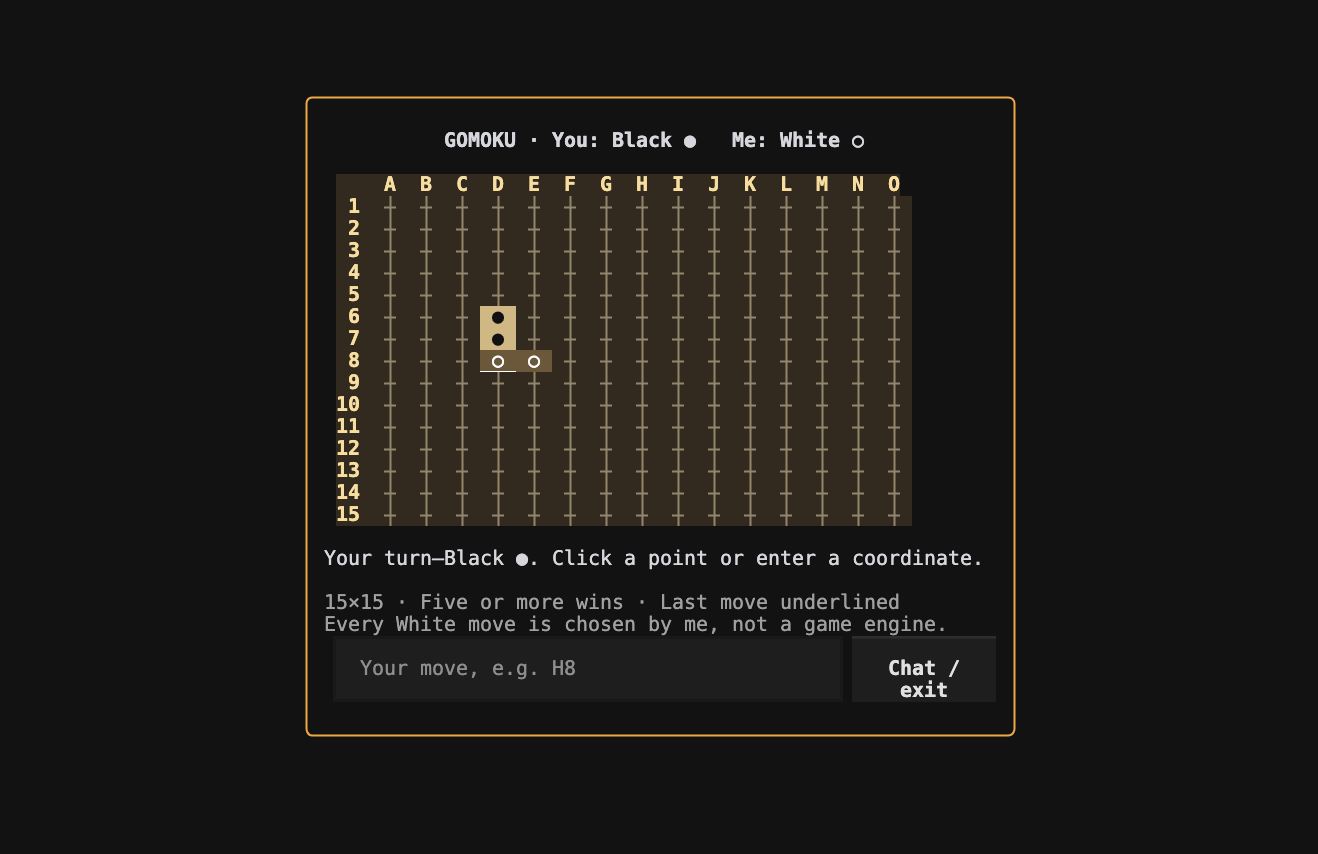
